<a href="https://colab.research.google.com/github/shubhamraut0209/Data-Science-Projects-Simplilearn/blob/main/Insurance_Factor_identification_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Shubham Umesh Raut | Data Science with R Programming | 5th August 2024 | Insurance Factor identification**



# ***DESCRIPTION***



**Background of Problem Statement :**



> The data gives the details of the third party motor insurance claims in Sweden for the year 1977. In Sweden, all motor insurance companies apply identical risk arguments to classify customers, and thus their portfolios and their claims statistics can be combined. The data were compiled by a Swedish Committee on the Analysis of Risk Premium in Motor insurance.



**Project Objective :**



> The Committee was asked to look into the problem of analyzing the real influence on the claims of the risk arguments and to compare this structure with the actual tariff.



**Domain :** Insurance

**Dataset Description :**



> The insurance dataset holds 7 variables and the description of these variables are given below:


*   **Kilometers :-** Kilometers travelled per year


1.   **<1000**
2.   **1000 - 15000**
3.   **15000 - 20000**
4.   **20000 - 25000**
5.   **>25000**


*   **Zone :-** Geographical zone


1.   Stockholm, Goteborg, and Malmo with the surroundings
2.   Other large cities with surroundings
3.   Smaller citieswith the surroundings in southern Sweden
4.   Rural areas in southern Sweden
5.   Smaller cities with surroundings in northern Sweden
6.   Rural areas in northern Sweden
7.   Gotland


*   **Bonus :-** No claims bonus; equal to the number of years, plus one, since the last claim.
*   **Make :-** 1-8 represents eight different common car models. All other models are combined in class 9.


*   **Insured :-** The number of insured in policy-years.
*   **Claims :-** Number of claims


*   **Payment :-** The total value of payments in SKr (Swedish Krona)

# **Analysis Tasks**



*   The committee is interested to know each field of the data collected through descriptive analysis to gain basic insights into the dataset and to prepare for further analysis.

*   The total value of payment by an insurance company is an important factor to be monitored. So the committee has decided to find whether this payment is related to the number of claims and the number of insured policy years. They also want to visualize the results for better understanding.

*   The committee wants to figure out the reasons for insurance payment increase and decrease. So they have decided to find whether distance, location, bonus, make, and insured amount or claims are affecting the payment or all or some of these are affecting it.

*   The insurance company is planning to establish a new branch office, so they are interested to find at what location, kilometre, and bonus level their insured amount,claims, and payment gets increased.

*   The committee wants to understand what affects their claim rates so as to decide the right premiums for a certain set of situations. Hence, they need to find whether the insured amount, zone, kilometre, bonus, or make affects the claim rates and to what extent.

In [ ]:
# Installing and importing necessary libraries

In [ ]:
install.packages("plyr")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [ ]:
install.packages("caTools")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependency ‘bitops’




In [ ]:
library(readxl)
library(plyr)
library(caTools)
library(tidyverse)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::arrange()   masks plyr::arrange()
✖ purrr::compact()   masks plyr::compact()
✖ dplyr::count()     masks plyr::count()
✖ dplyr::desc()      masks plyr::desc()
✖ dplyr::failwith()  masks plyr::failwith()
✖ dplyr::filter()    masks stats::filter()
✖ dplyr::id()        masks plyr::id()
✖ dplyr::lag()       masks stats::lag()
✖ dplyr::mutate()    masks plyr::mutate()
✖ dplyr::rename()    masks plyr::rename()
✖ dplyr::summarise() masks plyr::summarise()
✖ dplyr::summarize() masks plyr::summarize()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [ ]:
install.packages("e1071")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependency ‘proxy’




In [ ]:
library(e1071)

In [ ]:
install.packages("caret")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘listenv’, ‘parallelly’, ‘future’, ‘globals’, ‘shape’, ‘future.apply’, ‘numDeriv’, ‘progressr’, ‘SQUAREM’, ‘diagram’, ‘lava’, ‘prodlim’, ‘iterators’, ‘clock’, ‘gower’, ‘hardhat’, ‘ipred’, ‘timeDate’, ‘foreach’, ‘ModelMetrics’, ‘pROC’, ‘recipes’, ‘reshape2’




In [ ]:
library(caret)

Loading required package: lattice


Attaching package: ‘caret’


The following object is masked from ‘package:purrr’:

    lift




In [ ]:
install.packages("randomForest")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [ ]:
library(randomForest)

randomForest 4.7-1.1

Type rfNews() to see new features/changes/bug fixes.


Attaching package: ‘randomForest’


The following object is masked from ‘package:dplyr’:

    combine


The following object is masked from ‘package:ggplot2’:

    margin




In [ ]:
# Loading the dataset
insurance_data=read.csv("/content/Insurance_factor_identification.csv")

In [ ]:
# View the dataset
view(insurance_data)

In [ ]:
# Problem Statement 1:
## Basic insights into the dataset and to prepare for further analysis.

In [ ]:
# Getting dimension of the dataset
dim(insurance_data)

[1] 2182    7

In [ ]:
# we can see that the data has 2182 rows and 7 columns

In [ ]:
# Getting the summary of the dataset
summary(insurance_data)

   Kilometres         Zone          Bonus            Make      
 Min.   :1.000   Min.   :1.00   Min.   :1.000   Min.   :1.000  
 1st Qu.:2.000   1st Qu.:2.00   1st Qu.:2.000   1st Qu.:3.000  
 Median :3.000   Median :4.00   Median :4.000   Median :5.000  
 Mean   :2.986   Mean   :3.97   Mean   :4.015   Mean   :4.992  
 3rd Qu.:4.000   3rd Qu.:6.00   3rd Qu.:6.000   3rd Qu.:7.000  
 Max.   :5.000   Max.   :7.00   Max.   :7.000   Max.   :9.000  
    Insured              Claims           Payment        
 Min.   :     0.01   Min.   :   0.00   Min.   :       0  
 1st Qu.:    21.61   1st Qu.:   1.00   1st Qu.:    2989  
 Median :    81.53   Median :   5.00   Median :   27404  
 Mean   :  1092.20   Mean   :  51.87   Mean   :  257008  
 3rd Qu.:   389.78   3rd Qu.:  21.00   3rd Qu.:  111954  
 Max.   :127687.27   Max.   :3338.00   Max.   :18245026  

In [ ]:
# There are some 0 values in Claims and Payment even though the car has been insured.
# This indicates that no Claim or Payment has been made for that datapoint(s)

In [ ]:
# Getting structure of the dataset
str(insurance_data)

'data.frame':	2182 obs. of  7 variables:
 $ Kilometres: int  1 1 1 1 1 1 1 1 1 1 ...
 $ Zone      : int  1 1 1 1 1 1 1 1 1 1 ...
 $ Bonus     : int  1 1 1 1 1 1 1 1 1 2 ...
 $ Make      : int  1 2 3 4 5 6 7 8 9 1 ...
 $ Insured   : num  455.1 69.2 72.9 1292.4 191 ...
 $ Claims    : int  108 19 13 124 40 57 23 14 1704 45 ...
 $ Payment   : int  392491 46221 15694 422201 119373 170913 56940 77487 6805992 214011 ...


In [ ]:
# we come to know that all the parameters of the data is numerical and integer

In [ ]:
# Problem Statement 2:
## The total value of payment by an insurance company is an important factor to be monitored.
## So the committee has decided to find whether this payment is related to the number of claims and the number of insured policy years.
## They also want to visualize the results for better understanding.

In [ ]:
# To find we use cor() function if both Claims and sum insured correlated to payments
# To visualize we use plot with Claims as x-axis and Payment as y-axis.

In [ ]:
cor(insurance_data$Claims,insurance_data$Payment,method = "pearson")

[1] 0.9954003

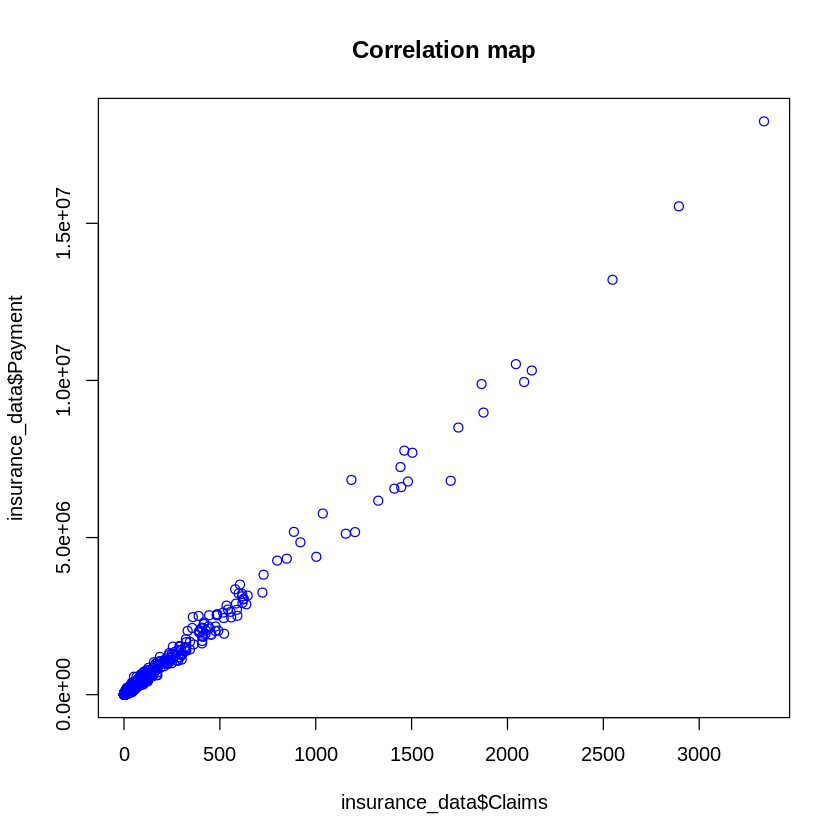

In [ ]:
plot(insurance_data$Claims,insurance_data$Payment,main="Correlation map",col = "blue")

In [ ]:
install.packages("corrplot")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [ ]:
library(corrplot)

corrplot 0.92 loaded



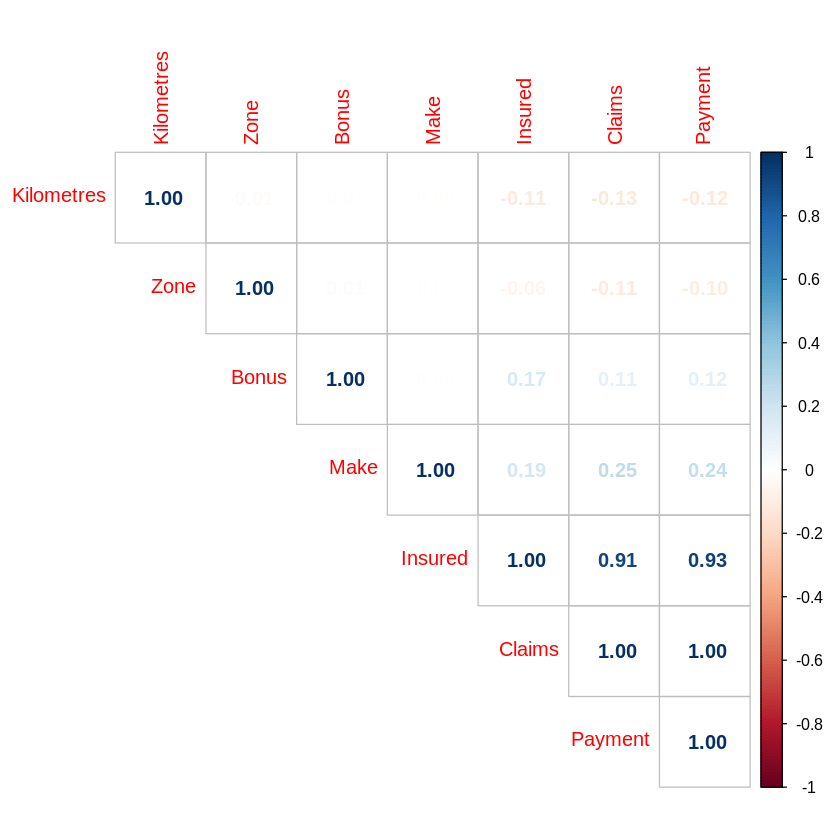

In [ ]:
corrplot(cor(insurance_data),method = "number",type = "upper" # shows only upper side)

In [ ]:
# The above matrix shows that payment vs claims is 1.00 and insured vs payment is 0.93
# hence indicate high correlation
# A strong positive correlation between Claims and Payment precisely 99.5 %
# Also from the plot, we can infer that as the Claims increase, the Payment increases.

In [ ]:
cor(insurance_data$Insured,insurance_data$Payment)

[1] 0.933217

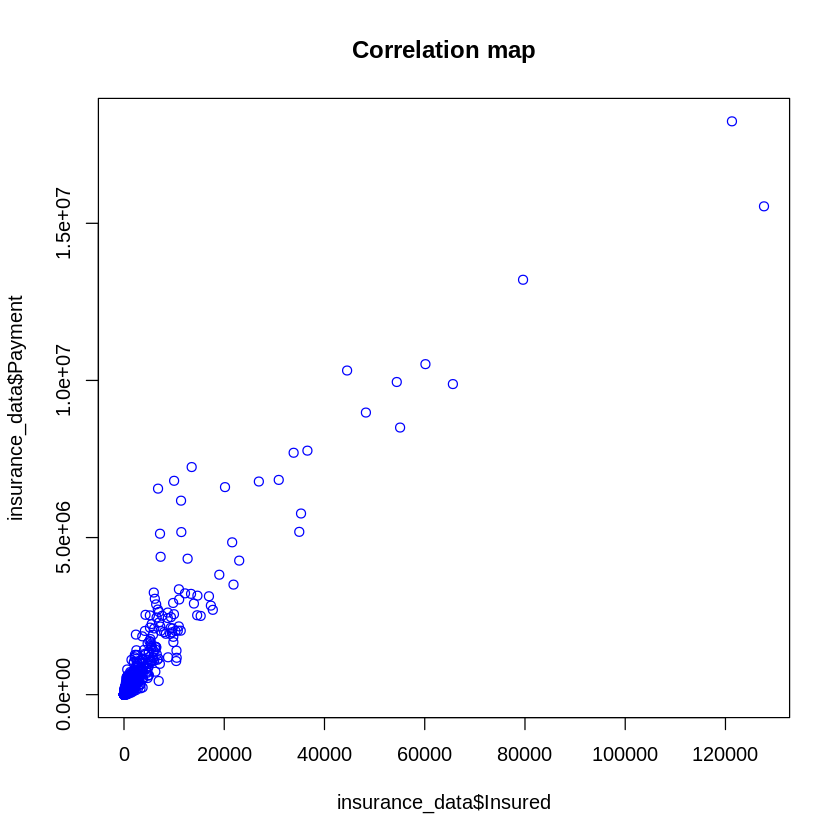

In [ ]:
plot(insurance_data$Insured,insurance_data$Payment,main = "Correlation map",col = "blue")

In [ ]:
# A strong positive Correlation between sum Insured and Payment precisely 93.3 %
# Similarly from the plot, we can infer that as the sum Insured increases, the Payment increases.

In [ ]:
# Problem Statement 3:
## The committee wants to figure out the reasons for the insurance payment increase and decrease.

In [ ]:
# For this we perform Linear Regression with Payment as dependent variable and others as independent variables.
Insurance_Payment_model=lm(Payment ~.,data = insurance_data)

In [ ]:
formula(Insurance_Payment_model)

Payment ~ Kilometres + Zone + Bonus + Make + Insured + Claims

In [ ]:
# Summary of our regression model
summary(Insurance_Payment_model)


Call:
lm(formula = Payment ~ ., data = insurance_data)

Residuals:
    Min      1Q  Median      3Q     Max 
-806775  -16943   -6321   11528  847015 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept) -2.173e+04  6.338e+03  -3.429 0.000617 ***
Kilometres   4.769e+03  1.086e+03   4.392 1.18e-05 ***
Zone         2.323e+03  7.735e+02   3.003 0.002703 ** 
Bonus        1.183e+03  7.737e+02   1.529 0.126462    
Make        -7.543e+02  6.107e+02  -1.235 0.216917    
Insured      2.788e+01  6.652e-01  41.913  < 2e-16 ***
Claims       4.316e+03  1.895e+01 227.793  < 2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 70830 on 2175 degrees of freedom
Multiple R-squared:  0.9952,	Adjusted R-squared:  0.9952 
F-statistic: 7.462e+04 on 6 and 2175 DF,  p-value: < 2.2e-16


In [ ]:
# from the above output, we can see that:
# 1] Kilometers, Zone, Insured, Claims are significant variables whose values will affect the Payment variable.
# 2] Make and Bonus variables have high p-value, hence they are not significant for the given data.
# 3] Also using the intercept and estimate values for all variables a linear equation can be formed which can be used to predict the Payment values.

In [ ]:
library(MASS)


Attaching package: ‘MASS’


The following object is masked from ‘package:dplyr’:

    select




In [ ]:
install.packages("equatiomatic")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘furrr’, ‘broom.mixed’




In [ ]:
library(equatiomatic)

In [ ]:
# Problem Statement 4 :
## To find when the Insured, Claims and Payment increases

In [ ]:
# we need to find the mean of the categorical values of Kilometre, Location, Bonus

In [ ]:
# Kilometre
kilometer_result=apply(insurance_data[,c(5,6,7)],2,function(x)tapply(x,insurance_data$Kilometres,mean))
kilometer_result

,Insured,Claims,Payment
1,1837.8163,75.59453,361899.35
2,1824.0288,89.27664,442523.78
3,1081.9714,54.16100,272012.58
4,398.9632,20.79493,108213.41
5,284.9475,18.04215,93306.12


In [ ]:
## Kilometre group 5 has the lowest Claims and Payment & group 2 has the highest Claims and Payment

In [ ]:
# Location/Zone
Zone_result=apply(insurance_data[,c(5,6,7)],2,function(x)tapply(x,insurance_data$Zone,mean))
Zone_result

,Insured,Claims,Payment
1,1036.17175,73.568254,338518.95
2,1231.48184,67.625397,319921.52
3,1362.95870,63.295238,307550.85
4,2689.38041,101.311111,537071.76
5,384.80188,19.047923,93001.84
6,802.68457,32.577778,175528.47
7,64.91071,2.108844,9948.19


In [ ]:
## Zone 7 has the lowest Insured, Claims and Payment while Zone 4 has the highest
## Most of the Payments and Claims comes from Zones 1 to 4

In [ ]:
# Bonus
Bonus_result=apply(insurance_data[,c(5,6,7)],2,function(x)tapply(x,insurance_data$Bonus,mean))
Bonus_result

,Insured,Claims,Payment
1,525.5502,62.50489,282921.99
2,451.0754,34.23397,163316.62
3,397.4737,24.97419,122656.17
4,360.3867,20.35161,98498.12
5,437.3936,22.82109,108790.50
6,805.8167,39.94286,197723.82
7,4620.3728,157.22222,819322.48


In [ ]:
## Bonus group 7 has drastically high in terms of Insured, Claims and Payment compared to the other 6 groups.

In [ ]:
# Problem Statement 5 :
## To check whether the Insured amount, Zone, Kilometre, Bonus, Make affects the Claims rates and to what extent.

In [ ]:
# we are going to fit linear regression model with Claims as dependent variable and Kilometre, Zone, Bonus, Make, Insured as independent variables.
Claims_model=lm(insurance_data$Claims ~ insurance_data$Kilometres + insurance_data$Zone + insurance_data$Bonus + insurance_data$Make +
  insurance_data$Insured)

In [ ]:
# Summary of the regression model
summary(Claims_model)


Call:
lm(formula = insurance_data$Claims ~ insurance_data$Kilometres + 
    insurance_data$Zone + insurance_data$Bonus + insurance_data$Make + 
    insurance_data$Insured)

Residuals:
     Min       1Q   Median       3Q      Max 
-1214.57   -25.18    -9.41    10.04  1301.78 

Coefficients:
                            Estimate Std. Error t value Pr(>|t|)    
(Intercept)               37.1230027  7.1270679   5.209 2.08e-07 ***
insurance_data$Kilometres -3.9648601  1.2255209  -3.235  0.00123 ** 
insurance_data$Zone       -6.2924300  0.8647405  -7.277 4.75e-13 ***
insurance_data$Bonus      -4.2468101  0.8707236  -4.877 1.15e-06 ***
insurance_data$Make        6.7725342  0.6755390  10.025  < 2e-16 ***
insurance_data$Insured     0.0318697  0.0003158 100.933  < 2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 80.14 on 2176 degrees of freedom
Multiple R-squared:  0.8425,	Adjusted R-squared:  0.8421 
F-statistic:  2328 on 5 and 2176 DF,  p-v

In [ ]:
## From the above output, looking at the p-values, we can infer that all of our independent variables are highly significant.
## And have a strong influence on the Claims variable

In [ ]:
# Hence we can conclude that Insured amount, Zone, Kilometre, Bonus and Make strongly affects the Claim rates.